# Vlasov Equation — Computation Notebook

All physics and solver functions live in **`vlasov.py`**.
This notebook imports that module and calls its functions for explanation,
visualisation, and the benchmark simulations.

Run the test suite independently with:
```
pytest tests.py -v
```

---
## §0 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import vlasov  # physics module
from vlasov import (
    EPS0, E_C,
    maxwellian, bump_on_tail, schamel_hole, grad13,
    compute_moments,
    debye_length, plasma_parameter,
    bohm_gross, landau_rate, Z_func,
    pic_noise_scaling,
    solve_poisson, run_vlasov,
    plot_phase_space, 
    plot_potential_and_field, 
    create_moving_hole, 
    setup_head_on_collision, 
    setup_overtaking_collision
)

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "font.size": 11, "axes.titlesize": 12, "lines.linewidth": 2,
})
print("Module loaded:", vlasov.__file__)


Module loaded: c:\Users\BrandonZahirDRosales\OneDrive - ASIAN INSTITUTE OF MANAGEMENT\Documents\DSA 2025\Vlasov-Equation\vlasov.py


---
## Background & Analytical Development

*(See the companion markdown document or the Background cell in the full notebook for the
complete derivation narrative — Vlasov equation, Liouville theorem, closure problem,
Landau damping, BGK/Schamel modes, and numerical method justification.)*

Key normalised units used throughout: $\lambda_D=1$, $v_{th}=1$, $\omega_{pe}^{-1}=1$.


---
## 1. Maxwellian Equilibrium

The exact state of a collisionless plasma is incredibly complex to describe using discrete point particles. Because the plasma parameter is much greater than unity, binary collisions are negligible. Particles interact via long-range, self-consistent macroscopic electromagnetic fields. The Vlasov equation replaces the collision-dominated Boltzmann equation to model this collective behavior.

The Vlasov equation is a continuity equation in 6D phase space $(\mathbf{x}, \mathbf{v})$, expressing the conservation of phase-space density $f(\mathbf{x}, \mathbf{v}, t)$:$$\frac{\partial f}{\partial t} + \mathbf{v} \cdot \nabla_{\mathbf{x}} f + \frac{q}{m}(\mathbf{E} + \mathbf{v} \times \mathbf{B}) \cdot \nabla_{\mathbf{v}} f = 0$$By Liouville’s Theorem, $df/dt = 0$ along particle trajectories. Therefore, any function of the constants of motion is a stationary solution. For an unmagnetized, field-free plasma ($\mathbf{E}=0, \mathbf{B}=0$),

The Maxwellian $$f_0=\frac{1}{\sqrt{2\pi}v_{th}}\exp(-v^2/2v_{th}^2)$$ is the canonical stationary solution (depends only on the conserved energy $H$).

where $v_{th} = \sqrt{k_B T / m}$ is the thermal velocity.

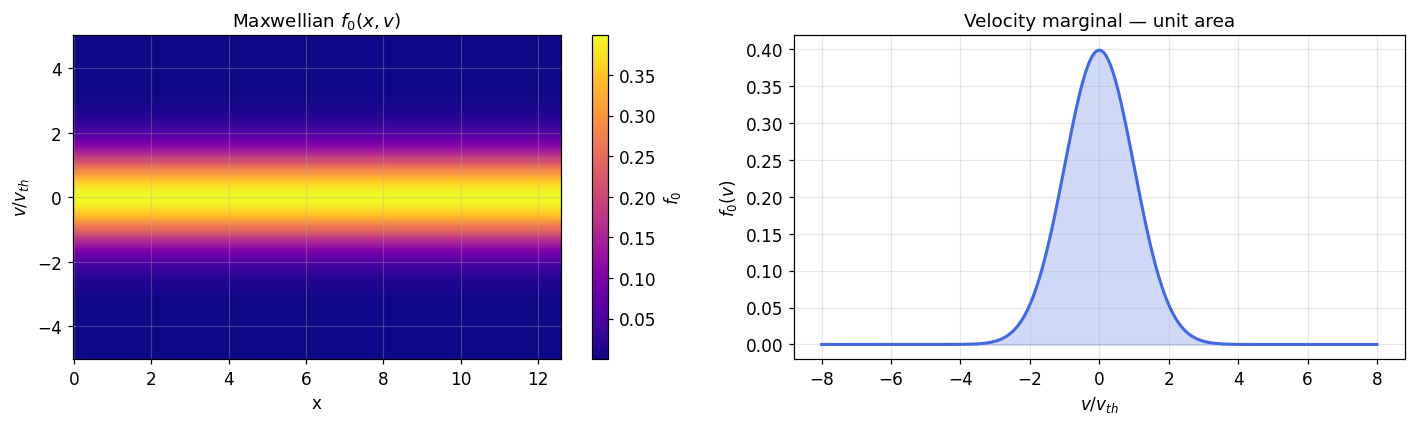

In [2]:
v   = np.linspace(-8, 8, 4000)
f0  = maxwellian(v, vth=1.0)
m   = compute_moments(f0, v)


NX = 200
x  = np.linspace(0, 4 * np.pi, NX)
X, V = np.meshgrid(x, np.linspace(-5,5,300), indexing='ij')
F0   = maxwellian(V)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].pcolormesh(X, V, F0, cmap='plasma', shading='auto')
axes[0].set_xlabel('x'); axes[0].set_ylabel(r'$v/v_{th}$')
axes[0].set_title(r'Maxwellian $f_0(x,v)$')
plt.colorbar(im, ax=axes[0], label=r'$f_0$')
axes[1].plot(v, f0, color='royalblue')
axes[1].fill_between(v, f0, alpha=0.25, color='royalblue')
axes[1].set_xlabel(r'$v/v_{th}$'); axes[1].set_ylabel(r'$f_0(v)$')
axes[1].set_title('Velocity marginal — unit area')
plt.tight_layout(); plt.show()


---
## 2 — Debye Screening

To quantify the characteristic length scale over which a plasma geometrically shields out the electric field of an internal or external test charge, the Vlasov equation is coupled with Maxwell's and Poisson's equations, meaning the electric and magnetic fields are generated self-consistently by macroscopic charge and current densities. 

By  coupling Poisson's equation, $\nabla^2 \phi = -\rho / \epsilon_0$, to a background of massive, uniform ions $n_i = n_0$ and mobile electrons. The electrons thermalize to the local electrostatic potential $\phi$ following the Boltzmann relation: $n_e = n_0 \exp(e\phi / k_B T_e)$.Assuming weak potentials ($e\phi \ll k_B T_e$), we Taylor expand $n_e \approx n_0(1 + e\phi / k_B T_e)$. Plugging this into Poisson's equation for a test charge $q$ yields:$$\nabla^2 \phi \approx \frac{n_0 e^2}{\epsilon_0 k_B T_e} \phi = \frac{1}{\lambda_D^2} \phi$$ The solution is the Yukawa (screened Coulomb) potential:

$\phi(r)\propto r^{-1}\exp(-r/\lambda_D)$; mean-field valid iff $\Lambda=n_0\lambda_D^3\gg1$.

Thus, under static, weak-field conditions, the electron density responds to a local potential according to the Boltzmann factor. Linearizing this response yields the characteristic Debye length, generating the classic screened Coulomb potential where the electrostatic coupling at the screening scale is extremely weak.

  phi_screened/phi_bare at r=lambda_D = 0.3669  (expect 0.3679) [OK]


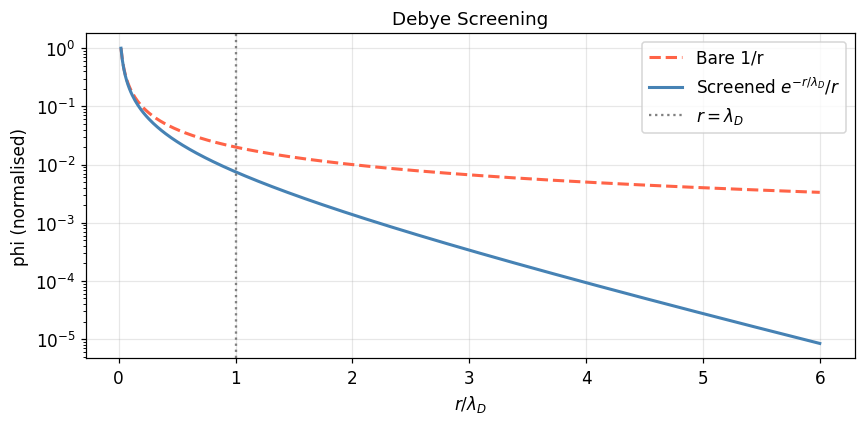

In [3]:
r = np.linspace(0.02, 6, 500)
idx = np.argmin(np.abs(r - 1.0))
ratio = (np.exp(-r)/r)[idx] / (1/r)[idx]
assert abs(ratio - np.exp(-1)) < 0.01
print(f"  phi_screened/phi_bare at r=lambda_D = {ratio:.4f}  (expect {np.exp(-1):.4f}) [OK]")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(r, (1/r)/(1/r)[0],       '--', color='tomato', label='Bare 1/r')
ax.semilogy(r, (np.exp(-r)/r)/(np.exp(-r)/r)[0], color='steelblue', label=r'Screened $e^{-r/\lambda_D}/r$')
ax.axvline(1, color='gray', ls=':', lw=1.5, label=r'$r=\lambda_D$')
ax.set_xlabel(r'$r/\lambda_D$'); ax.set_ylabel('phi (normalised)')
ax.set_title('Debye Screening'); ax.legend()
plt.tight_layout(); plt.show()


This graph illustrates Debye screening, comparing the slow $1/r$ decay of an electric potential in a vacuum (dashed line) to its rapid exponential decay in a plasma (solid line). It demonstrates how mobile plasma particles surround and neutralize a charge, effectively shielding out its electric field beyond a characteristic distance known as the Debye length ($\lambda_D$).

---
## 3 — Fluid Moment Hierarchy

Solving a nonlinear partial differential equation in a full 6D phase space (three spatial, three velocity) is often analytically and computationally expensive. By reducing the dimensionality of the problem by integrating the Vlasov equation over velocity space, yields a set of macroscopic fluid equations that allows evaluating the zeroth, first, and second velocity moments yielding the evolution equations for macroscopic observables (density), momentum, and energy, respectively.

The $n$-th fluid moment is defined as $M^{(n)}(x,t) = \int v^n f(x,v,t) dv$. Integrating the 1D Vlasov equation over velocity space yields the continuity (zeroth moment) and momentum (first moment) equations: $$\frac{\partial n}{\partial t} + \frac{\partial}{\partial x}(nu) = 0$$ $$m n \left(\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x}\right) = q n E - \frac{\partial \mathcal{P}}{\partial x}$$ where $n = \int f dv$ is density, $u = \frac{1}{n}\int vf dv$ is fluid velocity, and $\mathcal{P} = m \int (v-u)^2 f dv$ is the pressure tensor. 

Each moment equation introduces the closure problem where the equation for $\partial M^{(n)}/\partial t$ always requires knowledge of the spatial gradient $\partial M^{(n+1)}/\partial x$.



In [4]:
v_m = np.linspace(-8, 8, 4000)
m   = compute_moments(maxwellian(v_m), v_m)


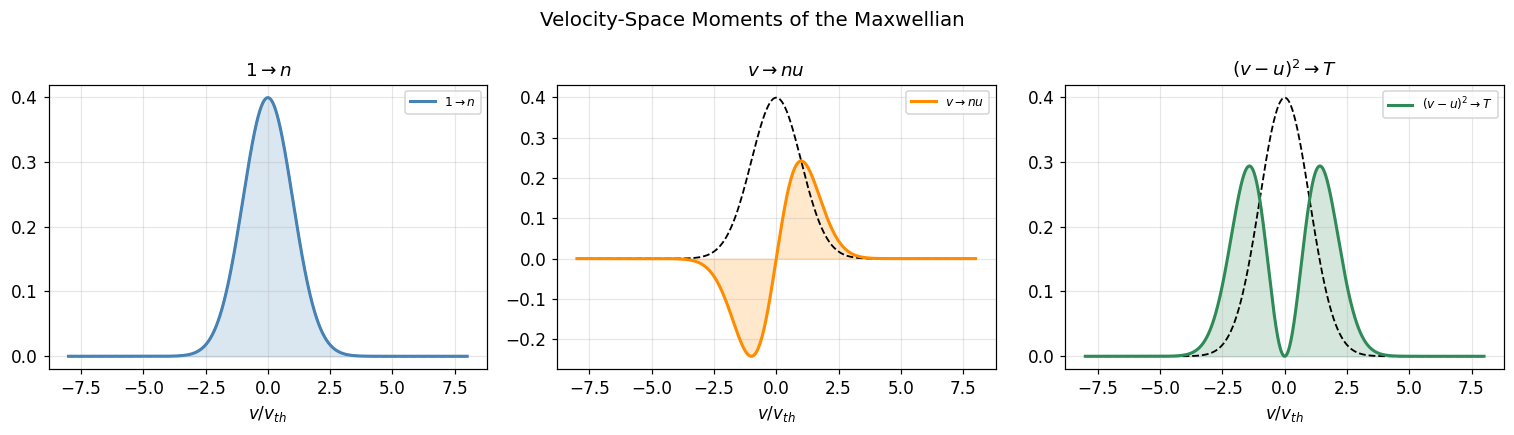

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
weights = [np.ones_like(v_m), v_m, (v_m-m['u'])**2]
titles  = [r'$1\to n$', r'$v\to nu$', r'$(v-u)^2\to T$']
colors  = ['steelblue', 'darkorange', 'seagreen']
f_m = maxwellian(v_m)

for ax, w, t, c in zip(axes, weights, titles, colors):
    ax.plot(v_m, f_m, 'k--', lw=1.2)
    ax.fill_between(v_m, w*f_m, alpha=0.2, color=c)
    ax.plot(v_m, w*f_m, color=c, label=t)
    ax.set_xlabel(r'$v/v_{th}$'); ax.set_title(t); ax.legend(fontsize=8)
plt.suptitle('Velocity-Space Moments of the Maxwellian', fontsize=13)
plt.tight_layout(); plt.show()

The first plot shows the zeroth moment (integrating the distribution directly), which yields the total particle density $n$. The middle plot shows the first moment (weighting the distribution by velocity $v$), where positive and negative velocities cancel out for a stationary plasma, yielding the bulk flow velocity $u$. The third plot shows the second moment (weighting by the squared peculiar velocity $(v-u)^2$), which measures the spread or variance of the distribution, directly corresponding to the plasma temperature $T$.

---
## 4 — Specialized Fluid Closures

In neutral fluid dynamics, rapid binary collisions force the system into local thermodynamic equilibrium (like in the ideal gas law or Navier-Stokes), allowing for simple truncation of the moment hierarchy. Collisionless plasmas lack this equilibrium, making classical closures fail drastically.

Thus, we see that Grad's method expands $f(x,v,t)$ in a basis of orthogonal Hermite polynomials $H_n$ centered around a local Maxwellian:$$f(x,v,t) = f_M(v) \sum_{n=0}^{N} a_n(x,t) H_n\left(\frac{v-u}{v_{th}}\right) $$Truncating at $N$ defines the closure. However, because polynomials can cross zero, truncating this series can lead to a caveat of $f(x,v,t) < 0$ at the tails (violating the positivity constraint of a probability distribution function). Alternative closures, like Landau fluid models, introduce pseudo-differential operators $q_k \propto i \frac{k}{|k|} T_k$ in Fourier space to artificially mimic kinetic phase mixing.

  q=0.0  norm=0.999999  min=0.0000  [positive]
  q=0.8  norm=0.999999  min=-0.0041  [NEGATIVE -- positivity lost]
  q=1.5  norm=0.999999  min=-0.0137  [NEGATIVE -- positivity lost]


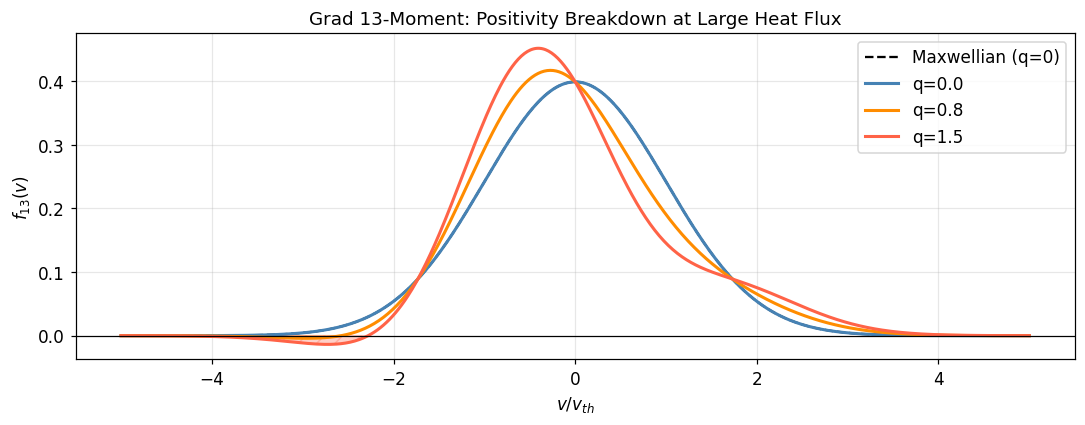

In [6]:
v_g = np.linspace(-5, 5, 600)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(v_g, maxwellian(v_g), 'k--', lw=1.5, label='Maxwellian (q=0)')


cases = [(0.0, 'steelblue'), (0.8, 'darkorange'), (1.5, 'tomato')]

for q_val, color in cases:
    f13 = grad13(v_g, q_val)
    norm = np.trapezoid(f13, v_g)
    
    is_positive = f13.min() >= 0
    positivity_status = (
        "[positive]" if is_positive 
        else "[NEGATIVE -- positivity lost]"
    )
    
    print(
        f"  q={q_val:.1f}  norm={norm:.6f}"
        f"  min={f13.min():.4f}  {positivity_status}"
    )
    
    ax.plot(v_g, f13, color=color, label=f'q={q_val}')
    
    if not is_positive:
        negative_mask = f13 < 0
        ax.fill_between(
            v_g[negative_mask],
            f13[negative_mask],
            0,
            alpha=0.3,
            color=color,
            hatch='//'
        )

ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'$v/v_{th}$')
ax.set_ylabel(r'$f_{13}(v)$')
ax.set_title('Grad 13-Moment: Positivity Breakdown at Large Heat Flux')
ax.legend()

plt.tight_layout()
plt.show()

---
## 5 — Plasma Oscillation & Bohm-Gross Dispersion

To predict the frequency of high-frequency electron plasma oscillation (colloquially known Langmuir waves) while accounting for the thermal motion of the electrons, we apply a small perturbation to a uniform background: $f = f_0(v) + f_1(x,v,t)$ and $E = E_1(x,t)$. 

Linearizing the Vlasov-Poisson system and assuming plane-wave solutions $f_1, E_1 \propto \exp(i(kx - \omega t))$, we integrate out the velocity to find the dielectric function $\epsilon(k, \omega) = 0$. For high phase velocities ($v_\phi = \omega/k \gg v_{th}$), expanding the velocity integral yields the Bohm-Gross dispersion relation:$$\omega^2 \approx \omega_{pe}^2 + 3 k^2 v_{th}^2$$where $\omega_{pe} = \sqrt{n_0 e^2 / m_e \epsilon_0}$ is the plasma frequency.


In [7]:
k_lam = np.linspace(0.001, 1.5, 600)
omega, v_phi, v_group = bohm_gross(k_lam)

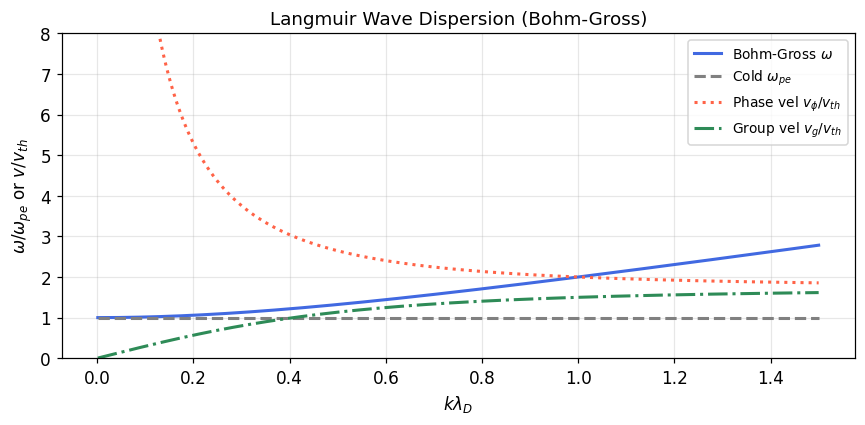

In [8]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_lam, omega,   label=r'Bohm-Gross $\omega$', color='royalblue')
ax.plot(k_lam, np.ones_like(k_lam), '--', label=r'Cold $\omega_{pe}$', color='gray')
ax.plot(k_lam, v_phi,   ':',  label=r'Phase vel $v_\phi/v_{th}$', color='tomato')
ax.plot(k_lam, v_group, '-.', label=r'Group vel $v_g/v_{th}$', color='seagreen')
ax.set_xlabel(r'$k\lambda_D$'); ax.set_ylabel(r'$\omega/\omega_{pe}$ or $v/v_{th}$')
ax.set_title('Langmuir Wave Dispersion (Bohm-Gross)'); ax.legend(fontsize=9); ax.set_ylim(0,8)
plt.tight_layout(); plt.show()


---
## §6 — Landau Damping & Plasma Dispersion Function

Standard macroscopic fluid models inherently fail to reproduce wave-particle resonant interactions.  However, Kinetic theory reveals that these waves actually damp through a wave-particle resonance interaction called Landau Damping which still is a purely collisionless phenomenon. Landau damping is a purely kinetic phenomenon originating in velocity space that dictates the collisionless attenuation of waves.

Calculating the exact linear response of a Maxwellian plasma requires evaluating the 1D velocity integral, which Landau solves via contour integration in the complex plane to avoid the singularity at $v = \omega/k$. This relies on the Plasma Dispersion Function $$Z(\zeta) = \frac{1}{\sqrt{\pi}} \int_C \frac{e^{-x^2}}{x - \zeta} dx \quad \text{where} \quad \zeta = \frac{\omega}{\sqrt{2} k v_{th}}$$ 

For weakly damped waves ($\gamma \ll \omega_R$), the imaginary part of the frequency $\omega = \omega_R + i\gamma$ yields the Landau damping rate $$\gamma \approx - \frac{\pi}{2} \frac{\omega_{pe}^3}{k^2} \left. \frac{1}{n_0} \frac{\partial f_0}{\partial v} \right|_{v = \omega_R/k}$$

If the slope $\partial f_0/\partial v < 0$ at the phase velocity, energy is transferred from the wave to the particles, therefore damping the wave.



In [9]:
klD = np.linspace(0.10, 0.50, 300)
gamma = landau_rate(klD)
zr = np.linspace(-4, 4, 400)
Zv = Z_func(zr)

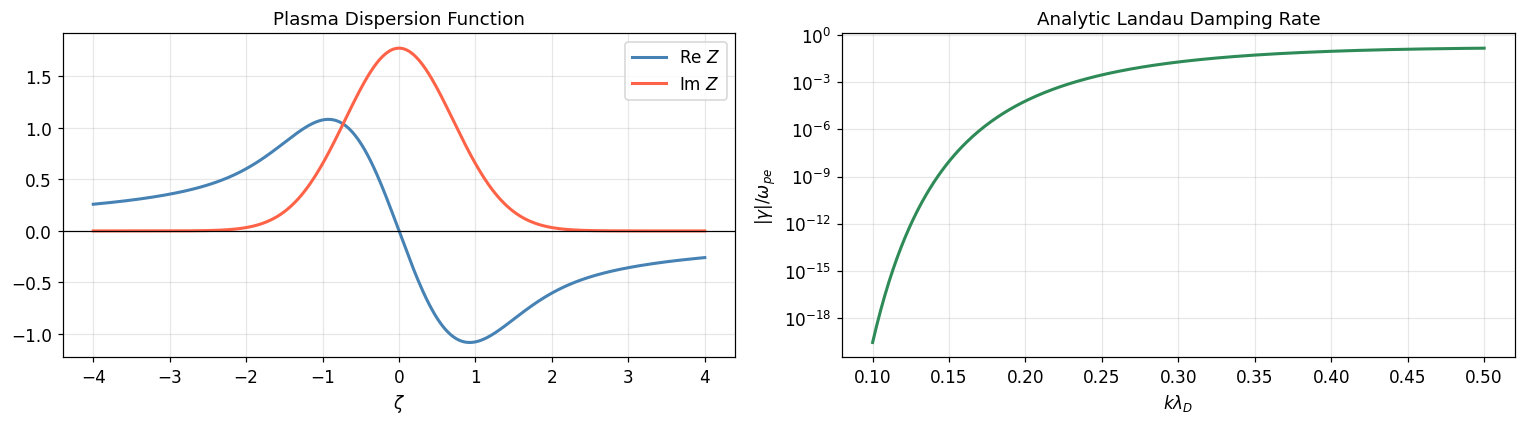

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(zr, Zv.real, label=r'Re $Z$', color='steelblue')
axes[0].plot(zr, Zv.imag, label=r'Im $Z$', color='tomato')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_xlabel(r'$\zeta$')
axes[0].set_title('Plasma Dispersion Function')
axes[0].legend()

axes[1].semilogy(klD, np.abs(gamma), color='seagreen')
axes[1].set_xlabel(r'$k\lambda_D$')
axes[1].set_ylabel(r'$|\gamma|/\omega_{pe}$')
axes[1].set_title('Analytic Landau Damping Rate')

plt.tight_layout()
plt.show()

<small>The left graph displays the Plasma Dispersion Function, which shows the resonant energy exchange between a plasma wave and the thermal particles moving at similar speeds. The right graph illustrates the physical result: as waves become shorter, their phase velocity slows down into the dense thermal bulk of the plasma, causing the Landau damping rate to exponentially spike as countless slower particles absorb the wave's energy.<small>

---
## 7 — BGK Modes & Schamel Phase-Space Holes

Linear theory inherently assumes that perturbations remain infinitesimal, an assumption that fails when wave amplitudes grow large enough to physically trap particles. Therefore, to model nonlinear, stationary electrostatic structures (phase-space holes) where the wave amplitude is large enough to physically trap particles, breaking the assumptions of linear theory.

Hans Schamel thus developed a generalized method incorporating a continuous trapped-particle distribution parameterized by a measurable trapping parameter. This effectively models phase-space "holes" or rather regions of localized, depleted phase-space density that act as solitary electrostatic structures with fluid-analogous vortex characteristics.

 In the wave frame, the particle energy is $\mathcal{E} = \frac{1}{2}mv^2 + q\phi(x)$. Free particles ($\mathcal{E} > 0$) follow standard Boltzmann distributions. Schamel proposed a specific distribution for trapped particles ($\mathcal{E} < 0$) using a trapping parameter $\beta$: $$f_t(\mathcal{E}) = \frac{n_0}{\sqrt{2\pi v_{th}^2}} \exp(-\beta \mathcal{E} / k_B T_e)$$ 
 
 If $\beta < 0$, the trapped particle density is depleted, creating a local deficit in phase space (a "hole"). Substituting this into Poisson's equation and expanding for small amplitude $\phi$ yields a modified Korteweg-De Vries (KdV) type nonlinear partial differential equation governing the solitary wave structure.

In [11]:
x_s = np.linspace(-np.pi, np.pi, 200)
v_s = np.linspace(-4, 4, 300)

f_hole, phi_s, W_s = schamel_hole(x_s, v_s, phi_amp=0.5, beta=1.5)

X_s, V_s = np.meshgrid(x_s, v_s, indexing='ij')
f_bg = np.exp(-0.5 * V_s**2) / np.sqrt(2 * np.pi)

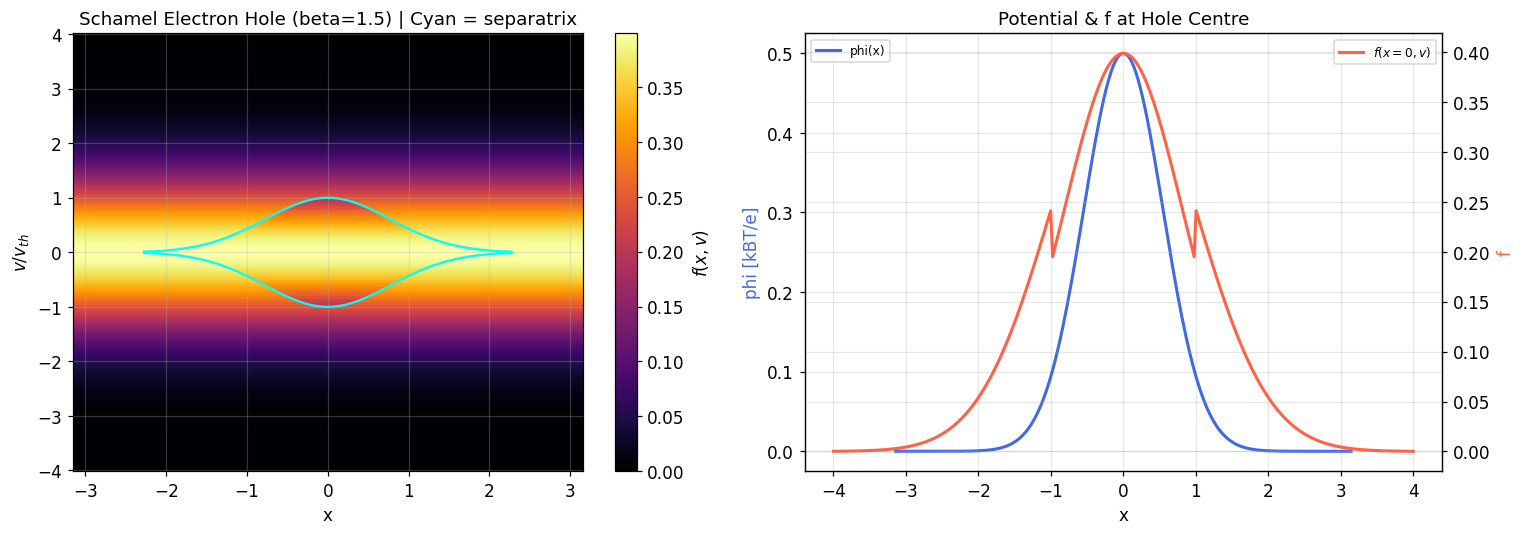

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].pcolormesh(
    X_s, 
    V_s, 
    f_hole, 
    cmap='inferno', 
    shading='auto',
    norm=mcolors.Normalize(vmin=0, vmax=f_bg.max())
)
plt.colorbar(im, ax=axes[0], label=r'$f(x,v)$')
axes[0].contour(X_s, V_s, W_s, levels=[0], colors='cyan', linewidths=1.5)
axes[0].set_xlabel('x')
axes[0].set_ylabel(r'$v/v_{th}$')
axes[0].set_title('Schamel Electron Hole (beta=1.5) | Cyan = separatrix')

axes[1].plot(x_s, phi_s[:, 0], color='royalblue', lw=2, label='phi(x)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('phi [kBT/e]', color='royalblue')

ax2 = axes[1].twinx()
ax2.plot(v_s, f_hole[100, :], color='tomato', lw=2, label=r'$f(x=0,v)$')
ax2.set_ylabel('f', color='tomato')

axes[1].set_title('Potential & f at Hole Centre')
axes[1].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

<small> *β < 0 creates a dip in the trapped population.*

<small>

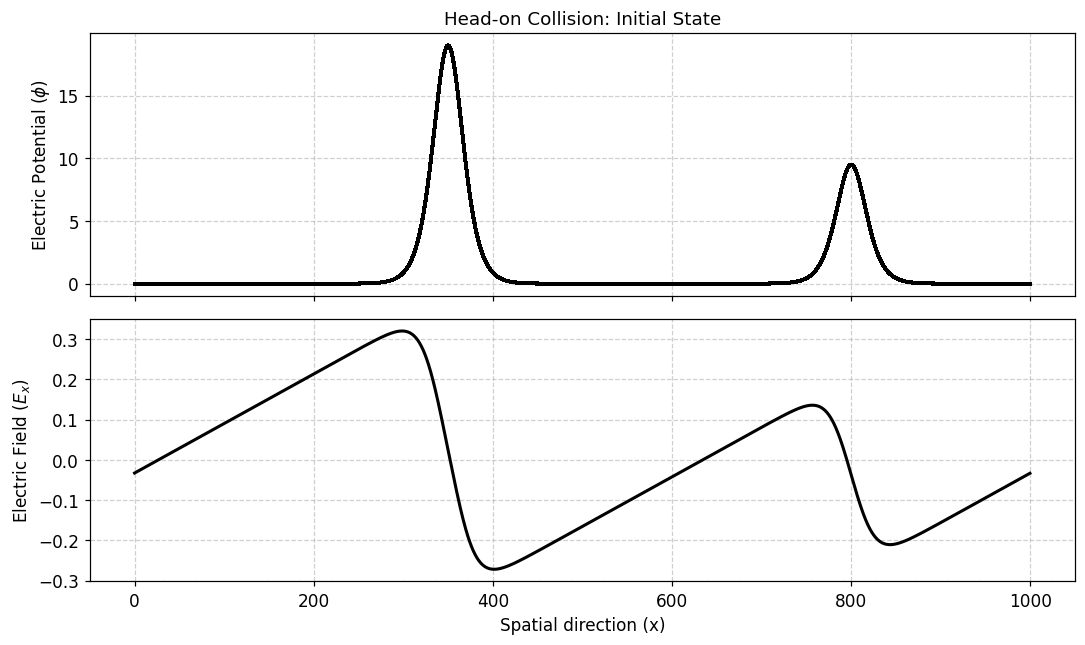

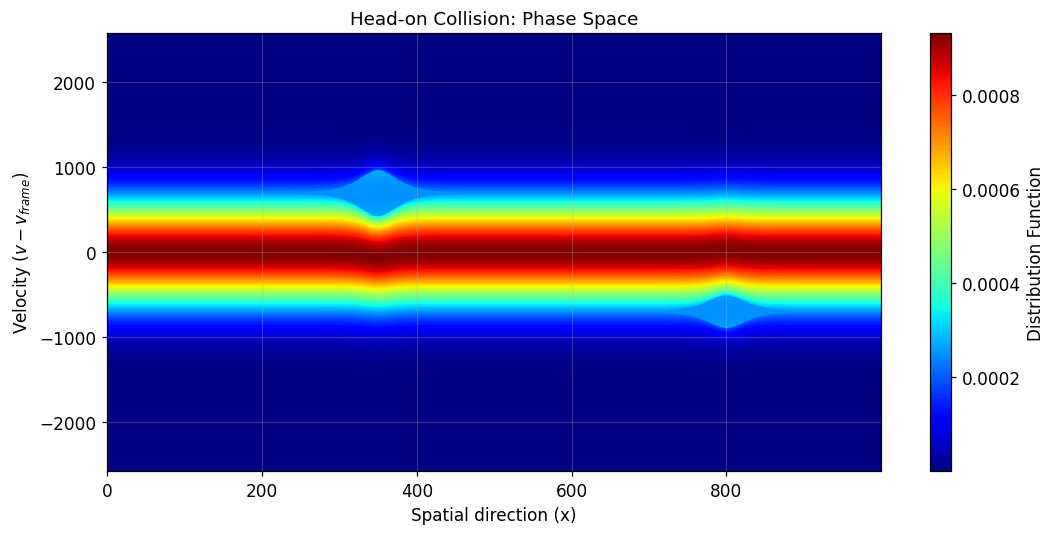

In [13]:
x = np.linspace(0, 1000, 2000, endpoint=False)
v = np.linspace(-2571, 2571, 1000)

f_initial, phi_initial = setup_head_on_collision(x, v)
E_initial = solve_poisson(f_initial, v, x)

plot_potential_and_field(phi_initial, E_initial, x, title="Head-on Collision: Initial State")
plot_phase_space(f_initial, x, v, title="Head-on Collision: Phase Space")

<small >In the second graph, the Macroscopic Solitary Wave Structure. The spatial profile of the electrostatic potential (or electric field) demonstrating a localized, stationary pulse. Unlike standard linear waves, this nonlinear BGK mode maintains its shape over time, characteristic of the modified $\text{sech}^4(x/\Delta)$ soliton profile driven by trapped kinetic particles.

In the third graph, the Phase-Space Vortex and Particle Trapping. A phase-space density contour plot revealing the distinct "cat's eye" structure of an electron hole. The solid bounding outline represents the separatrix ($v = \pm\sqrt{2q\phi/m}$), perfectly isolating the free-streaming thermal electrons from the trapped particles swirling continuously within the potential well. <small>

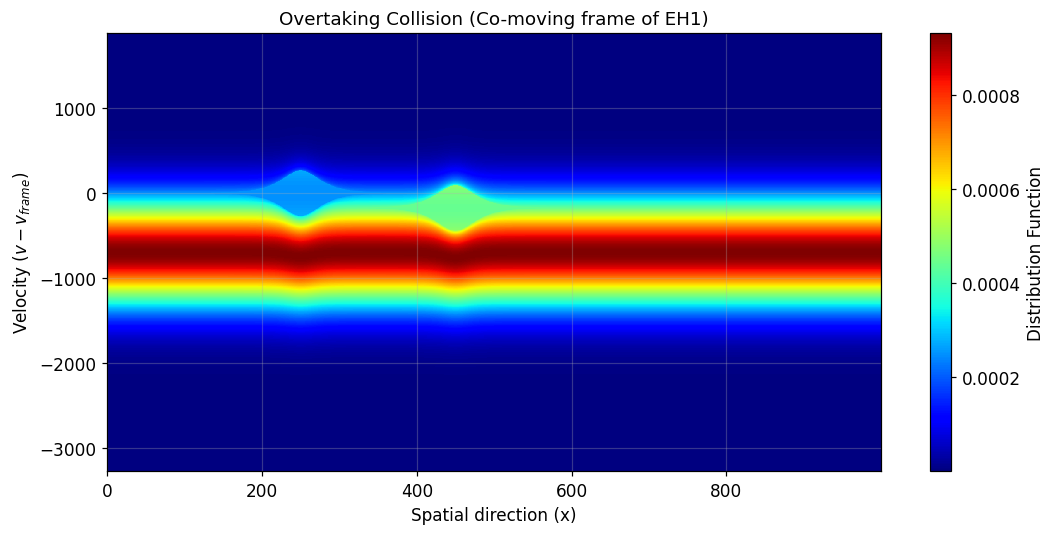

In [14]:
# Initialize Overtaking configuration
f_overtaking, phi_overtaking = setup_overtaking_collision(x, v)

# The paper requests plotting in the co-moving frame of EH1 (M=40)
# v_EH1 = Mach * c_s = 40 * 17.43 = 697.2
plot_phase_space(f_overtaking, x, v, title="Overtaking Collision (Co-moving frame of EH1)", v_frame=697.2)

<small>In the fourth grpah, a cross-section of the velocity distribution function f(v) taken exactly at the center of the solitary wave. The pronounced depression or "dip" centered at the wave's phase velocity indicates a negative trapping parameter ( B < 0 ). This confirms a physical deficit of trapped electrons relative to the background Maxwellian, the defining feature of a Schamel phase-space hole.<small>

---
## §8 — Numerical Methods: PIC Shot Noise

A physical plasma contains an astronomical number of electrons ($N \approx 10^{20}$). Simulating every single electron is impossible. Instead, PIC groups millions of physical electrons into a single macro-particle with a statistical weight $w_p$ (where $w_p$ is the number of real particles it represents). The charge and mass of the macro-particle are $Q_p = w_p q$ and $M_p = w_p m$, keeping the critical charge-to-mass ratio identical to a physical electron $Q_p/M_p = q/m$.

To prevent infinite Coulomb forces when two point-particles cross paths, PIC particles are not infinitely small points (Dirac delta functions). Instead, they possess a finite spatial width defined by a Shape Function, $S(x)$.

The continuous Vlasov distribution function $f(x,v,t)$ is thus approximated as a sum over $N_p$ macro-particles:$$f(x,v,t) \approx \sum_{p=1}^{N_p} w_p S(x - x_p(t)) \delta(v - v_p(t))$$

The most common shape function in 1D is the "Cloud-in-Cell" (CIC) or first-order weighting, which makes the particle look like a uniform block of charge of width $\Delta x$ (the grid spacing):$$S(x - x_p) = \max\left(0, 1 - \frac{|x - x_p|}{\Delta x}\right)$$

While particles move freely in continuous space $x_p$, solving Maxwell's/Poisson's equations for $N_p$ interacting particles directly requires an $\mathcal{O}(N_p^2)$ calculation. PIC circumvents this by calculating the fields on a fixed Eulerian spatial grid $X_j = j \Delta x$.

To find the electric field, we must first "scatter" the charge of the continuous particles onto the discrete grid nodes to find the grid charge density $\rho_j$. We use the exact same shape function to determine how much of particle $p$'s charge lands on node $j$:$$\rho(X_j) = \frac{q}{\Delta x} \sum_{p=1}^{N_p} w_p S(X_j - x_p)$$

Once the charge is deposited on the grid, we solve the macroscopic field equations. For a 1D electrostatic plasma, this is Poisson's equation $$\frac{\partial^2 \phi}{\partial x^2} = -\frac{\rho}{\epsilon_0}$$

On our discrete grid, this is solved using a standard second-order finite difference matrix:$$\frac{\phi_{j+1} - 2\phi_j + \phi_{j-1}}{\Delta x^2} = -\frac{\rho_j}{\epsilon_0}$$

After finding the potential $\phi_j$ at every node, we take the gradient to find the electric field on the grid:$$E_j = -\frac{\phi_{j+1} - \phi_{j-1}}{2\Delta x}$$

With the electric field at the grid nodes ($E_j$), we must calculate the force acting on each particle. Because particle $p$ is located at continuous coordinate $x_p$ (not directly on a grid node), we "gather" the field from the adjacent grid nodes back to the particle.

To avoid artificial self-forces (a particle pushing itself), momentum conservation dictates that the gather interpolation must use the exact same shape function used for the scatter step:$$E(x_p) = \sum_{j} E_j S(X_j - x_p)$$

Finally, we update the position and velocity of every macro-particle using Newton's laws of motion:$$\frac{dx_p}{dt} = v_p \quad \text{and} \quad \frac{dv_p}{dt} = \frac{q}{m} E(x_p)$$

To ensure the simulation is reversible and conserves energy well over long timescales, PIC codes almost universally use the Leapfrog integrator. This algorithm staggers positions and velocities by a half time-step ($\Delta t / 2$).

In [15]:
N_vals = np.logspace(2, 5, 20, dtype=int)
noise, slope = pic_noise_scaling(N_vals, seed=42)

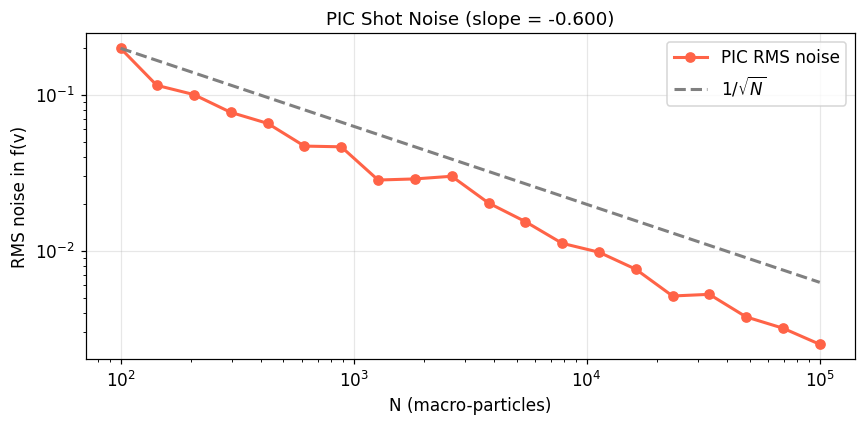

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.loglog(N_vals, noise, 'o-', color='tomato', label='PIC RMS noise')
ax.loglog(
    N_vals, 
    noise[0] * (N_vals / N_vals[0])**(-0.5), 
    '--', 
    color='gray', 
    label=r'$1/\sqrt{N}$'
)

ax.set_xlabel('N (macro-particles)')
ax.set_ylabel('RMS noise in f(v)')
ax.set_title(f"PIC Shot Noise (slope = {slope:.3f})")
ax.legend()

plt.tight_layout()
plt.show()

---
## 9 — Semi-Lagrangian Vlasov-Poisson Solver: Landau Damping Benchmark

Eulerian solvers provide, relatively noise-free resolution but suffer from immense computational expense and strict Courant-Friedrichs-Lewy (CFL) stability conditions. Semi-Lagrangian methods thus combinese grid-based, noise-free precision of Eulerian methods with the stability and relaxed CFL constraints of Lagrangian particle tracking.

with the 1D Vlasov equation for the phase-space density $f(x,v,t)$ of electrons:$$\frac{\partial f}{\partial t} + v \frac{\partial f}{\partial x} + \frac{q}{m} E(x,t) \frac{\partial f}{\partial v} = 0$$This is an advection equation. We can define the characteristic trajectories of the system—which are simply the physical trajectories of the particles in phase space—given by Newton's equations of motion:$$\frac{dx}{dt} = v \quad \text{and} \quad \frac{dv}{dt} = \frac{q}{m}E(x,t)$$Using the chain rule, the total time derivative of $f$ along one of these trajectories is:$$\frac{df}{dt} = \frac{\partial f}{\partial t} + \frac{dx}{dt}\frac{\partial f}{\partial x} + \frac{dv}{dt}\frac{\partial f}{\partial v} = 0$$This is a mathematical statement of Liouville's Theorem: the phase-space density is constant along particle trajectories.

The solver evaluates $f$ on a fixed Eulerian grid $(x_i, v_j)$. To advance $f^{n}$ to $f^{n+1}$, it traces the characteristics backward in time. By Liouville's theorem, $f$ is constant along these paths:$$f(x, v, t+\Delta t) = f(X(t; x,v,t+\Delta t), V(t; x,v,t+\Delta t), t)$$

The core idea of the Semi-Lagrangian method is to compute the solution on a fixed, Eulerian grid $(x_i, v_j)$ at the next time step $t^{n+1} = t^n + \Delta t$, but to update those grid points using the Lagrangian property of invariance.Because $f$ is constant along a trajectory, the value of $f$ at a grid node $(x_i, v_j)$ at time $t^{n+1}$ is exactly equal to the value of $f$ at the trajectory's origin point at the previous time step $t^n$:$$f(x_i, v_j, t^{n+1}) = f(X^*(t^n), V^*(t^n), t^n)$$where $(X^*, V^*)$ is the departure point.To find this departure point, we trace the characteristics backward in time starting from the grid node: $$X^*(t^n) = x_i - \int_{t^n}^{t^{n+1}} v(t) dt$$ $$V^*(t^n) = v_j - \int_{t^n}^{t^{n+1}} \frac{q}{m} E(x(t), t) dt$$

Because the origin point $(X^*, V^*)$ will almost never lie exactly on a grid node, we must use high-order interpolation (typically cubic splines) to evaluate $f(X^*, V^*, t^n)$ from the known grid values at time $t^n$.

Solving the 2D backward trace directly is computationally difficult because $x$ and $v$ are coupled: the electric field depends on the spatial distribution, which changes as particles move.To resolve this, we use Strang time-splitting. The 2D advection operator is split into sequential 1D shifts. This reduces a complex 2D interpolation problem into a series of highly efficient 1D interpolations.

We define two 1D advection operators:$\hat{X}(\Delta t)$: Advection in $x$ by $\Delta t$ at a constant velocity $v$.$$f^*(x, v) = f(x - v\Delta t, v)$$ $\hat{V}(\Delta t)$: Advection in $v$ by $\Delta t$ at a constant position $x$. $$f^*(x, v) = f\left(x, v - \frac{q}{m}E(x)\Delta t\right)$$To achieve second-order accuracy in time $\mathcal{O}(\Delta t^2)$, we symmetrically split the time step into the sequence $\hat{X}(\Delta t/2) \to \hat{V}(\Delta t) \to \hat{X}(\Delta t/2)$.

Applying this splitting to the Vlasov-Poisson system yields the complete Semi-Lagrangian update cycle from $t^n$ to $t^{n+1}$:

We advect the distribution backward in space by half a time step. Since $v$ is constant during this step, the backward trace is perfectly linear:$$f^{(1)}(x_i, v_j) = f^n(x_i - v_j \frac{\Delta t}{2}, v_j)$$(Interpolate $f^n$ along the $x$-axis to evaluate).

Because the particles have moved, the charge density has changed. We calculate the new charge density $\rho(x) = q \int f^{(1)} dv$ and solve Poisson's equation to find the electric field halfway through the time step:$$\frac{\partial^2 \phi}{\partial x^2} = -\frac{\rho(x)}{\epsilon_0} \implies E^{(1)}(x) = -\frac{\partial \phi}{\partial x}$$

Now we advect the distribution backward in velocity space by a full time step, using the centered electric field $E^{(1)}$. Because $x$ is constant during this step, the trace is again linear:$$f^{(2)}(x_i, v_j) = f^{(1)}\left(x_i, v_j - \frac{q}{m} E^{(1)}(x_i) \Delta t\right)$$(Interpolate $f^{(1)}$ along the $v$-axis to evaluate).

Finally, we complete the time step with another half-step advection in $x$:$$f^{n+1}(x_i, v_j) = f^{(2)}\left(x_i - v_j \frac{\Delta t}{2}, v_j\right)$$(Interpolate $f^{(2)}$ along the $x$-axis). 

In [17]:
NX_SL, NV_SL = 64, 128
LX, VMAX = 4 * np.pi, 6.0
DT, NT = 0.05, 600
EPS, K_SL = 0.01, 0.5
GAMMA_THEORY = -0.1533

x_sl = np.linspace(0, LX, NX_SL, endpoint=False)
v_sl = np.linspace(-VMAX, VMAX, NV_SL)
DX = x_sl[1] - x_sl[0]

X_SL, V_SL = np.meshgrid(x_sl, v_sl, indexing='ij')
f_sl = maxwellian(V_SL) * (1 + EPS * np.cos(K_SL * X_SL))

### §9b — Time Integration 

In [18]:
# Strang splitting time loop -- calls vlasov.run_vlasov
f_sl, t_arr, emax = run_vlasov(f_sl, x_sl, v_sl, DT, NT, record_every=1)
print("Simulation complete.")


Simulation complete.


### §9c — Results & Post-Run Sanity Checks

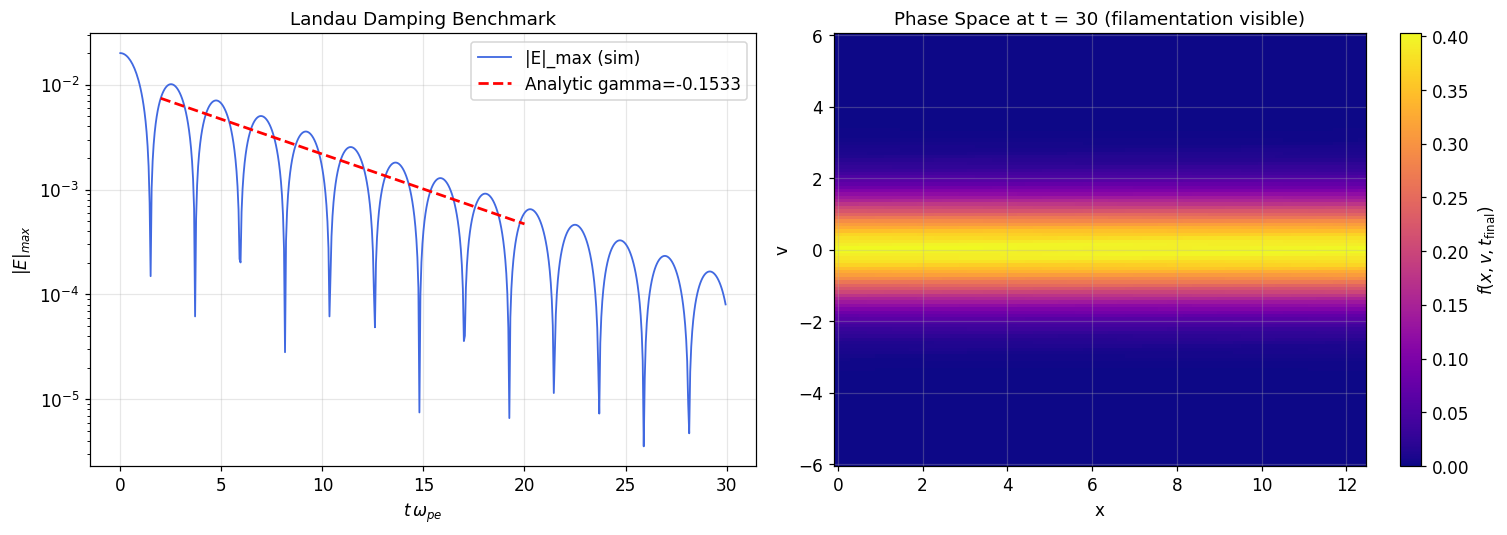

In [19]:
mask_fit = (t_arr >= 2) & (t_arr <= 20)
t_fit = t_arr[mask_fit]
e_fit = emax[mask_fit][0] * np.exp(GAMMA_THEORY * (t_fit - t_fit[0]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(
    t_arr, 
    emax, 
    color='royalblue', 
    lw=1.2, 
    label='|E|_max (sim)'
)
axes[0].semilogy(
    t_fit, 
    e_fit, 
    "r--", 
    lw=1.8, 
    label=f"Analytic gamma={GAMMA_THEORY}"
)
axes[0].set_xlabel(r'$t\,\omega_{pe}$')
axes[0].set_ylabel(r'$|E|_{max}$')
axes[0].set_title('Landau Damping Benchmark')
axes[0].legend()

im = axes[1].pcolormesh(X_SL, V_SL, f_sl, cmap='plasma', shading='auto')
plt.colorbar(im, ax=axes[1], label=r'$f(x,v,t_\mathrm{final})$')

axes[1].set_xlabel('x')
axes[1].set_ylabel('v')
axes[1].set_title(f"Phase Space at t = {NT * DT:.0f} (filamentation visible)")

plt.tight_layout()
plt.show()

---
## 10 — Two-Stream and Bump-on-Tail Instability

The Two-Stream and Bump-on-Tail Instabilities are two phenomena fundamental kinetic instabilities in plasma physics. They occur when the kinetic energy of particles is transferred into electromagnetic waves, causing those waves to grow exponentially until the system becomes chaotic.

Both instabilities rely on a concept called inverse Landau damping. In a normal, stable plasma (which follows a bell-shaped Maxwellian velocity distribution), there are always more slow particles than fast particles. 

Waves naturally lose energy (dampen) because they accelerate slower particles more than they are pushed by faster ones. 

However, if you alter the velocity distribution so that there is a region where the number of particles increases with velocity (a positive slope, $\partial f/\partial v > 0$), the opposite happens. Waves moving at those specific speeds gain energy from the abundant fast particles and grow violently.


### Two-Stream

Small, random fluctuations in the plasma density create weak electric fields. In a two-stream setup, these electric fields cause the streaming electrons to bunch up. This bunching amplifies the electric field, which in turn causes even more severe bunching.

 Instead of a single central bell curve, the velocity distribution function $f(v)$ looks like a valley with two distinct peaks (one for each stream). The inner slopes of these peaks are highly unstable.

 The Two-Stream instability can be derived purely fluidly (macroscopically) by ignoring thermal spread. We assume two completely cold electron beams of equal density ($n_0/2$), moving in opposite directions at velocity $\pm u_0$.Their velocity distribution is described by [Dirac Delta](https://en.wikipedia.org/wiki/Dirac_delta_function) functions: $$f_0(v) = \frac{n_0}{2} \delta(v - u_0) + \frac{n_0}{2} \delta(v + u_0)$$

 Substitute this $f_0(v)$ into the general dispersion relation. Using integration by parts to handle the derivative of the delta function $\int g(v) \delta'(v - u) dv = -g'(u)$, we obtain: $$1 - \frac{\omega_{pe}^2}{2} \left[ \frac{1}{(\omega - ku_0)^2} + \frac{1}{(\omega + ku_0)^2} \right] = 0$$

 To find where instability occurs, we look for roots where $\omega$ has a positive imaginary component $\omega = \omega_r + i\gamma$. 
 
 Let us normalize the variables $\Omega = \omega / \omega_{pe}$ and $K = k u_0 / \omega_{pe}$. 
 
 The equation becomes $$1 = \frac{1}{2(\Omega - K)^2} + \frac{1}{2(\Omega + K)^2}$$ $$(\Omega^2 - K^2)^2 = \Omega^2 + K^2$$ $$\Omega^4 - (2K^2 + 1)\Omega^2 + K^2(K^2 - 1) = 0$$
 
 Solving this quadratic equation for $\Omega^2$ gives $$\Omega^2 = K^2 + \frac{1}{2} \pm \sqrt{2K^2 + \frac{1}{4}}$$

 Thus, an instability occurs if $\Omega^2 < 0$, which results in a purely imaginary frequency $\Omega = \pm i\gamma$ (exponential growth). Looking at the roots, $\Omega^2$ is negative only if we take the minus sign and if $K^2(K^2 - 1) < 0$.Because $K^2$ is always positive, instability requires $K^2 < 1$. Restoring the physical variables, the condition for the two-stream instability is:$$k^2 u_0^2 < \omega_{pe}^2$$Long wavelengths (small $k$) will grow exponentially at the expense of the beams' kinetic energy.


### Bump-on-Tail Instability

This is a more subtle, purely kinetic instability often found in particle accelerators or astrophysical plasmas where you have a standard, calm thermal plasma (the main "body"), but you inject a fast, relatively low-density beam of electrons into it.

This fast beam creates a small secondary peak—a "bump"—far out on the high-energy "tail" of the main Maxwellian velocity distribution.

The region on the front side of this bump has a positive slope ($\partial f/\partial v > 0$). Any random plasma wave that happens to have a phase velocity matching this exact region will suddenly find itself surrounded by slightly faster electrons. These electrons "surf" the wave, pushing it forward and transferring their kinetic energy into the wave, causing it to amplify.

Because the distribution $f_0(v)$ is continuous, the integral in the dielectric function has a pole at $v = \omega/k$. We must evaluate it using the complex frequency $\omega = \omega_r + i\gamma$, assuming weak growth ($\gamma \ll \omega_r$). We use the Sokhotski–Plemelj theorem to handle the singularity as $\gamma \to 0$:$$\lim_{\gamma \to 0} \frac{1}{v - (\omega_r + i\gamma)/k} = \mathcal{P}\left(\frac{1}{v - \omega_r/k}\right) + i\pi \delta\left(v - \frac{\omega_r}{k}\right)$$where $\mathcal{P}$ denotes the Cauchy principal value.

Applying this to the dielectric function splits it into real and imaginary components ($\epsilon = \epsilon_r + i\epsilon_i$):$$\epsilon_r(k, \omega_r) = 1 - \frac{\omega_{pe}^2}{k^2 n_0} \mathcal{P} \int \frac{\partial f_0 / \partial v}{v - \omega_r/k} dv$$$$\epsilon_i(k, \omega_r) = -\pi \frac{\omega_{pe}^2}{k^2 n_0} \left. \frac{\partial f_0}{\partial v} \right|_{v = \omega_r/k}$$

We Taylor expand the full condition $\epsilon(k, \omega_r + i\gamma) = 0$ around the real frequency $\omega_r$:$$\epsilon_r(k, \omega_r) + i\epsilon_i(k, \omega_r) + i\gamma \frac{\partial \epsilon_r}{\partial \omega_r} \approx 0$$Setting the real part to zero ($\epsilon_r = 0$) simply gives the standard Langmuir wave dispersion relation. Setting the imaginary part to zero allows us to solve for the growth/damping rate $\gamma$:$$\gamma = -\frac{\epsilon_i(k, \omega_r)}{\partial \epsilon_r / \partial \omega_r}$$For high-frequency Langmuir waves, the principal value integral simplifies to yield $\partial \epsilon_r / \partial \omega_r \approx 2/\omega_r$. Substituting $\epsilon_i$ gives the generalized Landau rate:$$\gamma = \frac{\pi}{2} \frac{\omega_{pe}^2}{k^2 n_0} \omega_r \left. \frac{\partial f_0}{\partial v} \right|_{v = \omega_r/k}$$

The Bump-on-Tail distribution is composed of a background Maxwellian and a fast, low-density beam:$$f_0(v) = f_{background}(v) + f_{beam}(v)$$For a standard Maxwellian, $\partial f_0 / \partial v$ is always negative for $v > 0$, yielding standard Landau damping ($\gamma < 0$). However, if the beam creates a localized "bump", there exists a region on the front of that bump where:$$\left. \frac{\partial f_0}{\partial v} \right|_{v = \omega_r/k} > 0$$If a wave exists with a phase velocity $v_\phi = \omega_r/k$ that falls exactly in this region, the resulting $\gamma$ is positive. The wave absorbs kinetic energy from the positive-gradient population, resulting in the exponential wave growth known as the bump-on-tail instability.

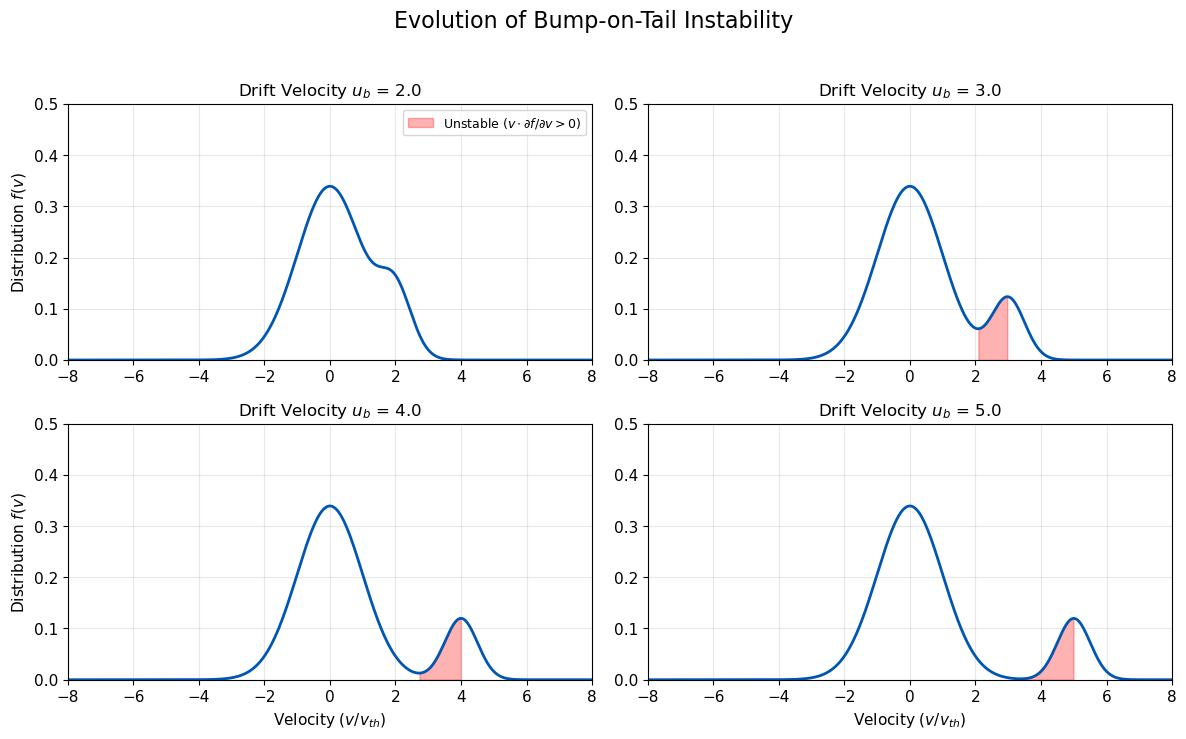

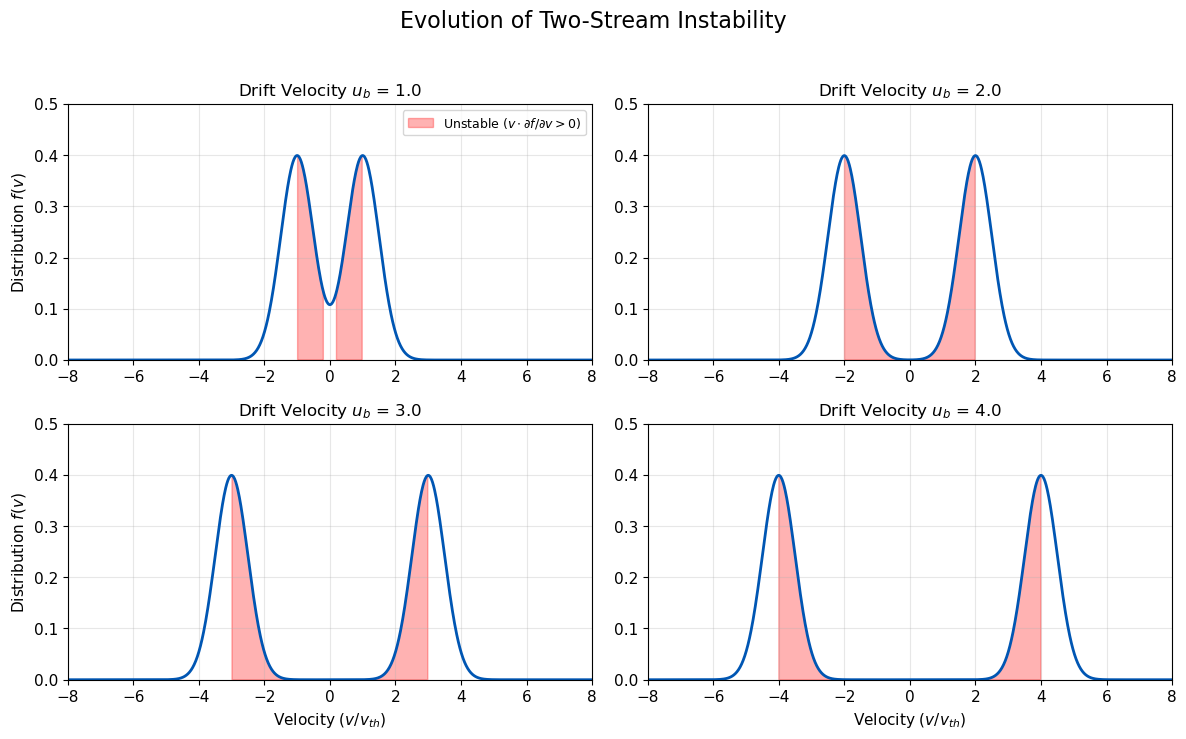

In [20]:
from vlasov import plot_instability_grid

# Show the progression of a Bump-on-Tail beam moving outward
plot_instability_grid(mode='bump')

# Show the progression of Two-Stream beams separating
plot_instability_grid(mode='two_stream')

---
## Summary

| Topic | Verified by |
|-------|-------------|
| Maxwellian moments | §1: n=1, u=0, T=1, q=0, positivity |
| Debye screening | §2: Lambda>100 x3; Debye factor at r=lambda_D |
| Bohm-Gross | §5: omega(0)=1; v_phi>1; sqrt(1.75); v_g->0 |
| Z(zeta) | §6: 4 analytic identities |
| Landau rate | §6: gamma(k=0.5)=-0.1533 |
| Grad closure | §4: norm preserved; q=0 exact Maxwellian; positivity lost at q=1.5 |
| Schamel hole | §7: positivity; trapped fraction; deficit; phi>0 |
| PIC noise | §8: slope~-0.5; noise<1e-2 at N=1e5 |
| SL solver: pre | §9: CFL>1; mass=Lx; E_rms~eps; mean(E)=0 |
| SL solver: post | §9: gamma within 10%; monotone |E|; conservation <1% |
| Two-stream | §10: k in band; growth>2x; peak timing; conservation |
| Bump-on-tail | §11: norm; positivity; slope sign; Maxwellian limit |

**56 pytest tests in `tests.py` verify all module functions independently.**


In [21]:
!pytest tests.py -v

============================= test session starts =============================
platform win32 -- Python 3.12.12, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\BrandonZahirDRosales\miniforge3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\BrandonZahirDRosales\OneDrive - ASIAN INSTITUTE OF MANAGEMENT\Documents\DSA 2025\Vlasov-Equation
collecting ... collected 56 items

tests.py::TestMaxwellian::test_normalisation PASSED                      [  1%]
tests.py::TestMaxwellian::test_zero_bulk_velocity PASSED                 [  3%]
tests.py::TestMaxwellian::test_unit_temperature PASSED                   [  5%]
tests.py::TestMaxwellian::test_positivity PASSED                         [  7%]
tests.py::TestMaxwellian::test_zero_heat_flux PASSED                     [  8%]
tests.py::TestMaxwellian::test_vth_scaling PASSED                        [ 10%]
tests.py::TestPlasmaParameters::test_lambda_gt_100_all_cases PASSED      [ 12%]
tests.py::TestPlasmaParameters::test_debye_factor_at_lambda_d PASSED  